# 01. Gymnasium 기본 환경 체험

**모듈**: M3 - 시뮬레이션 환경 + 센서 시뮬레이션
**날짜**: 2026-03-09

에이전트-환경 상호작용의 기본 루프를 이해합니다.

```
에이전트 ──action──→ 환경
   ↑                   │
   └──observation,──────┘
      reward, done
```

**이것이 우리 로봇의 기본 동작 방식!**
- 에이전트 = 우리 로봇 (나중에 V-JEPA + Flow Matching이 두뇌)
- 환경 = 장애물이 있는 세상
- observation = 5개 센서 데이터
- action = 이동 방향/속도

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

print(f'Gymnasium: {gym.__version__}')

Gymnasium: 1.2.3


## 1. CartPole 환경 실행

CartPole: 막대를 넘어지지 않게 수레를 좌/우로 밀기.
- **observation**: [수레위치, 수레속도, 막대각도, 막대각속도] = 4개 숫자
- **action**: 0(왼쪽) 또는 1(오른쪽)
- **reward**: 막대가 서 있으면 +1 (매 스텝)
- **done**: 막대가 넘어지거나 500스텝 도달

In [2]:
# CartPole 환경 생성
env = gym.make('CartPole-v1')

# 환경 정보 확인
print('=== CartPole 환경 정보 ===')
print(f'관측 공간: {env.observation_space}')  # Box(4,)
print(f'행동 공간: {env.action_space}')       # Discrete(2)
print(f'관측 shape: {env.observation_space.shape}')
print(f'행동 수: {env.action_space.n}')

# 한 에피소드 실행
obs, info = env.reset(seed=42)
print(f'\n초기 관측: {obs}')
print(f'  [수레위치={obs[0]:.3f}, 수레속도={obs[1]:.3f}, 막대각도={obs[2]:.3f}, 막대각속도={obs[3]:.3f}]')

# 3스텝 수동 실행
print(f'\n--- 수동 실행 ---')
for step in range(3):
    action = env.action_space.sample()  # 랜덤 행동
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    action_name = '왼쪽' if action == 0 else '오른쪽'
    print(f'Step {step+1}: action={action_name}, reward={reward}, done={done}')
    print(f'  obs: 위치={obs[0]:.3f}, 속도={obs[1]:.3f}, 각도={obs[2]:.3f}')

env.close()

=== CartPole 환경 정보 ===
관측 공간: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
행동 공간: Discrete(2)
관측 shape: (4,)
행동 수: 2

초기 관측: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
  [수레위치=0.027, 수레속도=-0.006, 막대각도=0.036, 막대각속도=0.020]

--- 수동 실행 ---
Step 1: action=왼쪽, reward=1.0, done=False
  obs: 위치=0.027, 속도=-0.202, 각도=0.036
Step 2: action=오른쪽, reward=1.0, done=False
  obs: 위치=0.023, 속도=-0.007, 각도=0.043
Step 3: action=오른쪽, reward=1.0, done=False
  obs: 위치=0.023, 속도=0.187, 각도=0.044


## 2. 에이전트-환경 루프

이것이 강화학습의 기본 구조이자, 우리 로봇의 동작 방식입니다.

```python
obs = env.reset()
while not done:
    action = agent.decide(obs)   # 관측 → 행동 결정
    obs, reward, done = env.step(action)  # 행동 → 새 관측
```

In [3]:
# 랜덤 에이전트로 100 에피소드 실행
env = gym.make('CartPole-v1')
n_episodes = 100
episode_rewards = []
episode_lengths = []

for ep in range(n_episodes):
    obs, _ = env.reset(seed=ep)
    total_reward = 0
    steps = 0
    
    while True:
        action = env.action_space.sample()  # 랜덤 행동
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        
        if terminated or truncated:
            break
    
    episode_rewards.append(total_reward)
    episode_lengths.append(steps)

env.close()

print(f'100 에피소드 결과 (랜덤 에이전트):')
print(f'  평균 보상: {np.mean(episode_rewards):.1f}')
print(f'  최대 보상: {np.max(episode_rewards):.0f}')
print(f'  평균 스텝: {np.mean(episode_lengths):.1f}')
print(f'\n랜덤이라 약 20스텝에서 실패 → 학습하면 500스텝까지 가능!')

100 에피소드 결과 (랜덤 에이전트):
  평균 보상: 22.3
  최대 보상: 73
  평균 스텝: 22.3

랜덤이라 약 20스텝에서 실패 → 학습하면 500스텝까지 가능!


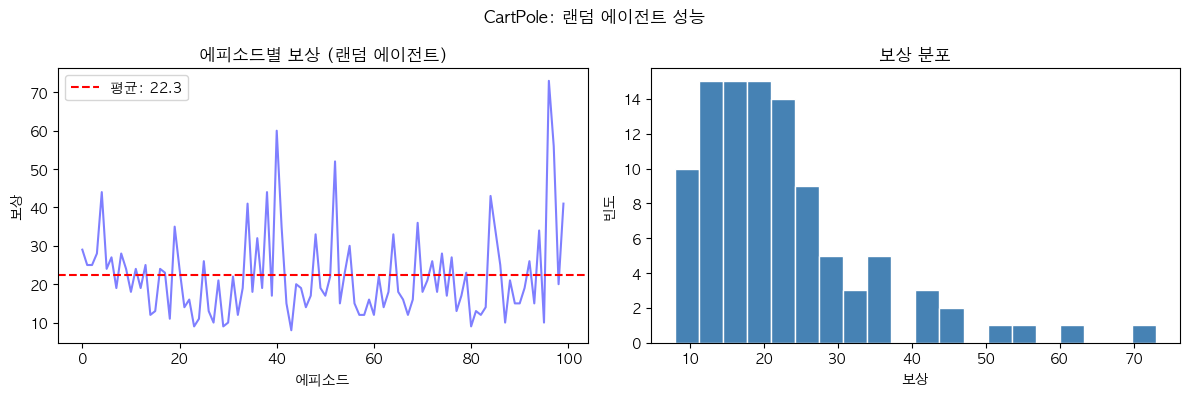

In [4]:
# 보상 그래프 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(episode_rewards, alpha=0.5, color='blue')
ax1.axhline(y=np.mean(episode_rewards), color='red', linestyle='--', label=f'평균: {np.mean(episode_rewards):.1f}')
ax1.set_title('에피소드별 보상 (랜덤 에이전트)')
ax1.set_xlabel('에피소드')
ax1.set_ylabel('보상')
ax1.legend()

ax2.hist(episode_rewards, bins=20, color='steelblue', edgecolor='white')
ax2.set_title('보상 분포')
ax2.set_xlabel('보상')
ax2.set_ylabel('빈도')

plt.suptitle('CartPole: 랜덤 에이전트 성능', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. 간단한 규칙 기반 에이전트

"막대가 오른쪽으로 기울면 오른쪽으로 밀기" — 간단한 규칙만으로도 성능이 향상됩니다.

In [5]:
def rule_agent(obs):
    """규칙 기반 에이전트: 막대 각도 방향으로 수레 이동"""
    angle = obs[2]  # 막대 각도
    return 1 if angle > 0 else 0  # 양수면 오른쪽, 음수면 왼쪽

# 규칙 에이전트 100 에피소드
env = gym.make('CartPole-v1')
rule_rewards = []

for ep in range(100):
    obs, _ = env.reset(seed=ep)
    total_reward = 0
    
    while True:
        action = rule_agent(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break
    
    rule_rewards.append(total_reward)

env.close()

print(f'규칙 에이전트 vs 랜덤 에이전트:')
print(f'  랜덤: 평균 {np.mean(episode_rewards):.1f}, 최대 {np.max(episode_rewards):.0f}')
print(f'  규칙: 평균 {np.mean(rule_rewards):.1f}, 최대 {np.max(rule_rewards):.0f}')
print(f'\n간단한 규칙만으로 {np.mean(rule_rewards)/np.mean(episode_rewards):.1f}배 향상!')
print(f'\n우리 프로젝트에서는:')
print(f'  M3: 규칙 기반 에이전트 (if 장애물 가까움 → 회피)')
print(f'  M8: Flow Matching 에이전트 (신경망이 부드러운 행동 생성)')
print(f'  M10: Triple Integration (LLM+V-JEPA+Flow Matching)')

규칙 에이전트 vs 랜덤 에이전트:
  랜덤: 평균 22.3, 최대 73
  규칙: 평균 41.0, 최대 58

간단한 규칙만으로 1.8배 향상!

우리 프로젝트에서는:
  M3: 규칙 기반 에이전트 (if 장애물 가까움 → 회피)
  M8: Flow Matching 에이전트 (신경망이 부드러운 행동 생성)
  M10: Triple Integration (LLM+V-JEPA+Flow Matching)


## 4. Gymnasium 공간(Space) 이해

커스텀 환경을 만들려면 공간 정의를 알아야 합니다.

| Space | 의미 | 예시 |
|-------|------|------|
| `Discrete(n)` | n개 중 하나 선택 | 행동: 상/하/좌/우 (4) |
| `Box(low, high, shape)` | 연속 범위 | 센서: 거리 0~1 (8,) |
| `Dict({...})` | 여러 공간 조합 | 5개 센서 묶음 |
| `MultiBinary(n)` | n개 이진값 | 장애물 존재 여부 |

In [6]:
from gymnasium import spaces

# 우리 프로젝트의 관측/행동 공간 설계
print('=== 우리 환경의 공간 설계 ===')
print()

# 관측 공간: 5개 센서를 Dict로 묶기
observation_space = spaces.Dict({
    'camera': spaces.Box(low=0, high=1, shape=(3, 64, 64), dtype=np.float32),
    'distance': spaces.Box(low=0, high=1, shape=(8,), dtype=np.float32),
    'audio': spaces.Box(low=-1, high=1, shape=(2, 100), dtype=np.float32),
    'imu': spaces.Box(low=-10, high=10, shape=(6,), dtype=np.float32),
})

# 행동 공간: 4방향 이동
action_space = spaces.Discrete(4)  # 0=상, 1=하, 2=좌, 3=우

print(f'관측 공간 (Dict):')
for name, space in observation_space.spaces.items():
    print(f'  {name:>10}: {space}')

print(f'\n행동 공간: {action_space}')
print(f'\n+ LLM 센서: 텍스트 (spaces로 표현 불가 → info dict에 포함)')

# 샘플 생성
print(f'\n--- 랜덤 샘플 ---')
sample_obs = observation_space.sample()
sample_action = action_space.sample()

for name, data in sample_obs.items():
    print(f'  {name:>10}: shape={data.shape}')
print(f'  action: {sample_action} ({["상","하","좌","우"][sample_action]})')

=== 우리 환경의 공간 설계 ===

관측 공간 (Dict):
       audio: Box(-1.0, 1.0, (2, 100), float32)
      camera: Box(0.0, 1.0, (3, 64, 64), float32)
    distance: Box(0.0, 1.0, (8,), float32)
         imu: Box(-10.0, 10.0, (6,), float32)

행동 공간: Discrete(4)

+ LLM 센서: 텍스트 (spaces로 표현 불가 → info dict에 포함)

--- 랜덤 샘플 ---
       audio: shape=(2, 100)
      camera: shape=(3, 64, 64)
    distance: shape=(8,)
         imu: shape=(6,)
  action: 0 (상)


## 5. 커스텀 환경 템플릿

`gymnasium.Env`를 상속해서 환경을 만드는 기본 구조입니다.
실습 2에서 이 구조로 장애물 회피 환경을 만듭니다.

In [7]:
class SimpleGridEnv(gym.Env):
    """간단한 2D 격자 환경 (커스텀 환경 템플릿)"""
    
    metadata = {'render_modes': ['human']}
    
    def __init__(self, grid_size=8):
        super().__init__()
        self.grid_size = grid_size
        
        # 행동: 4방향
        self.action_space = spaces.Discrete(4)
        # 관측: 에이전트 위치 (x, y)
        self.observation_space = spaces.Box(
            low=0, high=grid_size-1, shape=(2,), dtype=np.float32
        )
        
        # 목표 위치
        self.goal = np.array([grid_size-1, grid_size-1], dtype=np.float32)
        # 장애물
        self.obstacles = [
            np.array([3, 3]),
            np.array([3, 4]),
            np.array([4, 3]),
        ]
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = np.array([0.0, 0.0], dtype=np.float32)
        self.steps = 0
        return self.agent_pos.copy(), {}
    
    def step(self, action):
        # 이동: 0=상, 1=하, 2=좌, 3=우
        moves = {0: [0, 1], 1: [0, -1], 2: [-1, 0], 3: [1, 0]}
        new_pos = self.agent_pos + np.array(moves[action], dtype=np.float32)
        
        # 경계 체크
        new_pos = np.clip(new_pos, 0, self.grid_size - 1)
        
        # 장애물 체크
        hit_obstacle = any(np.array_equal(new_pos.astype(int), obs) for obs in self.obstacles)
        
        if not hit_obstacle:
            self.agent_pos = new_pos
        
        self.steps += 1
        
        # 보상 계산
        dist_to_goal = np.linalg.norm(self.agent_pos - self.goal)
        
        if dist_to_goal < 0.5:  # 목표 도달
            reward = 100.0
            terminated = True
        elif hit_obstacle:
            reward = -50.0
            terminated = True
        else:
            reward = -1.0  # 스텝 패널티
            terminated = False
        
        truncated = self.steps >= 100  # 최대 스텝
        
        return self.agent_pos.copy(), reward, terminated, truncated, {'steps': self.steps}

# 테스트
env = SimpleGridEnv(grid_size=8)
obs, _ = env.reset(seed=42)
print(f'초기 위치: {obs}')
print(f'목표 위치: {env.goal}')
print(f'장애물: {env.obstacles}')

# 몇 스텝 실행
actions = [3, 3, 0, 0, 3, 0]  # 오른쪽, 오른쪽, 위, 위, 오른쪽, 위
action_names = ['상', '하', '좌', '우']
print(f'\n--- 수동 에이전트 ---')
for a in actions:
    obs, reward, term, trunc, info = env.step(a)
    print(f'  {action_names[a]}: 위치={obs}, 보상={reward:.0f}, 종료={term}')
    if term or trunc:
        break

초기 위치: [0. 0.]
목표 위치: [7. 7.]
장애물: [array([3, 3]), array([3, 4]), array([4, 3])]

--- 수동 에이전트 ---
  우: 위치=[1. 0.], 보상=-1, 종료=False
  우: 위치=[2. 0.], 보상=-1, 종료=False
  상: 위치=[2. 1.], 보상=-1, 종료=False
  상: 위치=[2. 2.], 보상=-1, 종료=False
  우: 위치=[3. 2.], 보상=-1, 종료=False
  상: 위치=[3. 2.], 보상=-50, 종료=True


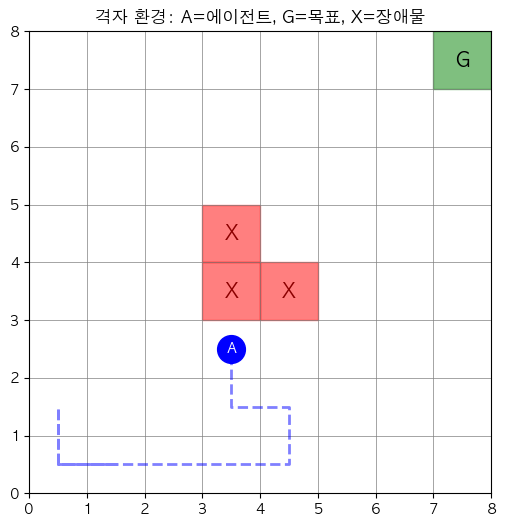

랜덤 에이전트: 19스텝 이동


In [8]:
# 격자 환경 시각화
def visualize_grid(env, path=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 격자
    for i in range(env.grid_size + 1):
        ax.axhline(y=i, color='gray', linewidth=0.5)
        ax.axvline(x=i, color='gray', linewidth=0.5)
    
    # 장애물
    for obs in env.obstacles:
        rect = plt.Rectangle(obs, 1, 1, color='red', alpha=0.5)
        ax.add_patch(rect)
        ax.text(obs[0]+0.5, obs[1]+0.5, 'X', ha='center', va='center', fontsize=14, color='darkred')
    
    # 목표
    goal_rect = plt.Rectangle(env.goal, 1, 1, color='green', alpha=0.5)
    ax.add_patch(goal_rect)
    ax.text(env.goal[0]+0.5, env.goal[1]+0.5, 'G', ha='center', va='center', fontsize=14, fontweight='bold')
    
    # 에이전트
    ax.plot(env.agent_pos[0]+0.5, env.agent_pos[1]+0.5, 'bo', markersize=20)
    ax.text(env.agent_pos[0]+0.5, env.agent_pos[1]+0.5, 'A', ha='center', va='center', color='white', fontweight='bold')
    
    # 경로
    if path:
        px = [p[0]+0.5 for p in path]
        py = [p[1]+0.5 for p in path]
        ax.plot(px, py, 'b--', alpha=0.5, linewidth=2)
    
    ax.set_xlim(0, env.grid_size)
    ax.set_ylim(0, env.grid_size)
    ax.set_aspect('equal')
    ax.set_title('격자 환경: A=에이전트, G=목표, X=장애물')
    return fig

# 에이전트 경로 기록
env = SimpleGridEnv()
obs, _ = env.reset(seed=42)
path = [obs.copy()]

for _ in range(50):
    action = env.action_space.sample()
    obs, reward, term, trunc, _ = env.step(action)
    path.append(obs.copy())
    if term or trunc:
        break

fig = visualize_grid(env, path)
plt.show()
print(f'랜덤 에이전트: {len(path)}스텝 이동')

## 6. 파이프라인 연결

Gymnasium의 `observation` → M1의 `SensorManager` → M2의 텐서/Encoder

In [9]:
print('=== Gymnasium → 우리 파이프라인 연결 ===')
print()
print('Gymnasium 표준 루프:')
print('  obs, info = env.reset()')
print('  while not done:')
print('      action = agent(obs)')
print('      obs, reward, done, info = env.step(action)')
print()
print('우리 루프 (M10 최종):')
print('  sensor_data, info = env.reset()  # 5개 센서 dict')
print('  while not done:')
print('      # M5: 각 센서 → Encoder → 16차원 벡터')
print('      # M6: 5개 벡터 → Fusion → 64차원 통합')
print('      # M7: V-JEPA → 미래 상태 예측')
print('      # M8: Flow Matching → 행동 시퀀스 생성')
print('      action = flow_matching.generate(fused_state)')
print('      sensor_data, reward, done, info = env.step(action)')
print('      # info["llm_interpretation"] = 상황 설명 텍스트')
print()
print('실습 1 완료! 다음: 커스텀 장애물 회피 환경 + 5개 센서 통합')

=== Gymnasium → 우리 파이프라인 연결 ===

Gymnasium 표준 루프:
  obs, info = env.reset()
  while not done:
      action = agent(obs)
      obs, reward, done, info = env.step(action)

우리 루프 (M10 최종):
  sensor_data, info = env.reset()  # 5개 센서 dict
  while not done:
      # M5: 각 센서 → Encoder → 16차원 벡터
      # M6: 5개 벡터 → Fusion → 64차원 통합
      # M7: V-JEPA → 미래 상태 예측
      # M8: Flow Matching → 행동 시퀀스 생성
      action = flow_matching.generate(fused_state)
      sensor_data, reward, done, info = env.step(action)
      # info["llm_interpretation"] = 상황 설명 텍스트

실습 1 완료! 다음: 커스텀 장애물 회피 환경 + 5개 센서 통합
